<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P3/TUGAS-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

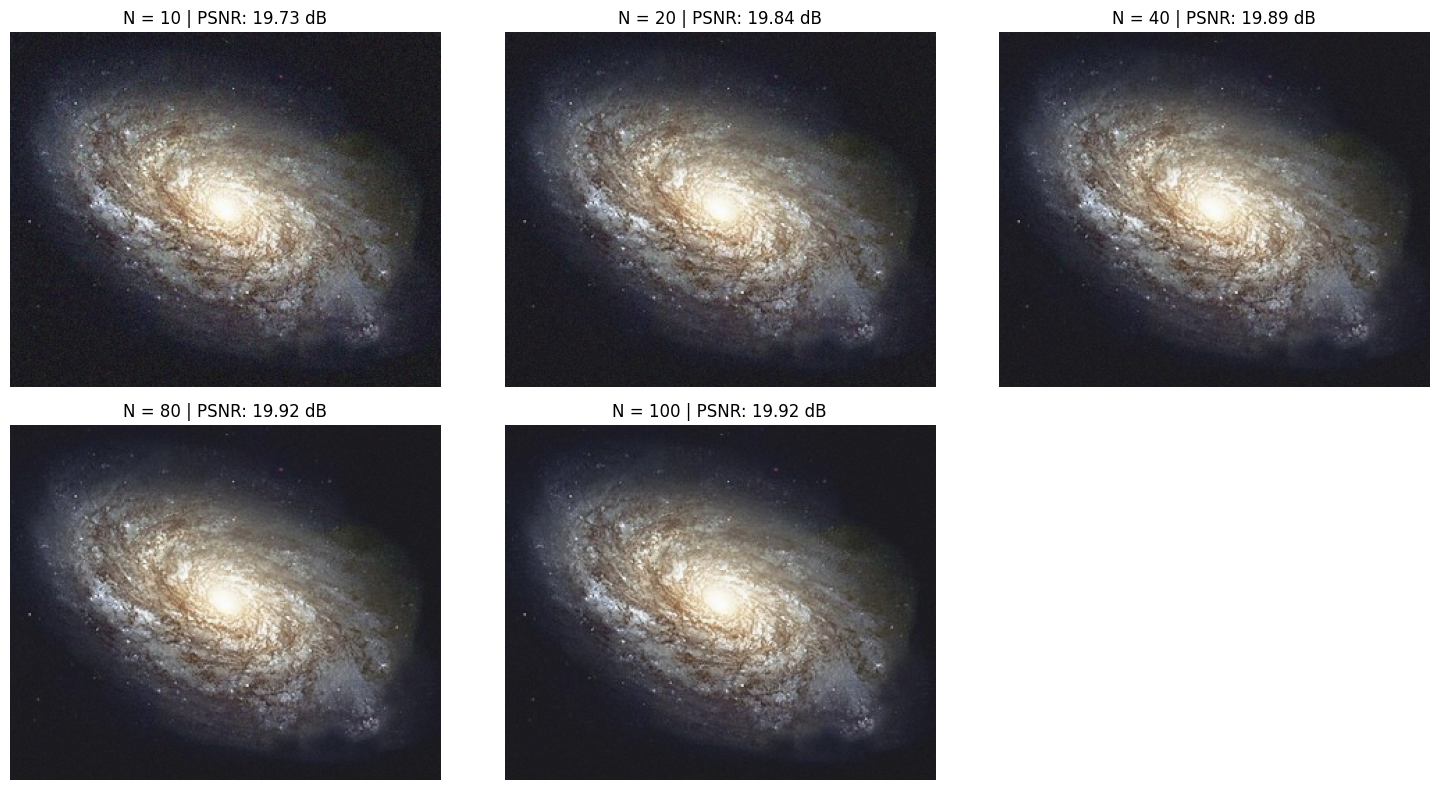


--- TABEL HASIL PSNR ---
Jumlah Citra:  10 | PSNR: 19.73 dB
Jumlah Citra:  20 | PSNR: 19.84 dB
Jumlah Citra:  40 | PSNR: 19.89 dB
Jumlah Citra:  80 | PSNR: 19.92 dB
Jumlah Citra: 100 | PSNR: 19.92 dB


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

original_path = '/content/drive/MyDrive/PCVK_2026/galaxy.jpg'
img_original = cv.imread(original_path)
img_original = cv.cvtColor(img_original, cv.COLOR_BGR2RGB)

noise_paths = glob.glob('/content/drive/MyDrive/PCVK_2026/noises/*.jpg')
cv_img = []
for img_p in noise_paths:
    n = cv.imread(img_p)
    cv_img.append(cv.cvtColor(n, cv.COLOR_BGR2RGB))

def calculate_psnr(original, denoised):
    mse = np.mean((original.astype(np.float64) - denoised.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

counts = [10, 20, 40, 80, 100]
results = []
psnr_values = []

plt.figure(figsize=(15, 8))

for idx, N in enumerate(counts):
    subset = np.array(cv_img[:N], dtype=np.float64)
    avg_img = np.mean(subset, axis=0)
    avg_img_uint8 = np.clip(avg_img, 0, 255).astype(np.uint8)

    psnr = calculate_psnr(img_original, avg_img_uint8)
    psnr_values.append(psnr)

    plt.subplot(2, 3, idx + 1)
    plt.imshow(avg_img_uint8)
    plt.title(f'N = {N} | PSNR: {psnr:.2f} dB')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n--- TABEL HASIL PSNR ---")
for N, psnr in zip(counts, psnr_values):
    print(f"Jumlah Citra: {N:3d} | PSNR: {psnr:.2f} dB")